<a href="https://colab.research.google.com/github/Krist0f0l0s/dino-polska-capm-analysis/blob/main/portfel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# @title
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score

**Zastosowanie modelu CAMP  do predykcji akcji Dino**

> Dodaj cytat blokowy



Bierzemy ceny akcji Dino i indeks giełdowy WIG20 z okresu 2017-2025, mierzone co tydzień. Jako roczną stopę waloru wolnego od ryzyka, czyli obligacji przyjmujemy $4.4$ procent (dlatego później podzielimy ją przez ilość tygodni).

In [ ]:
# @title
dnp = pd.read_csv("/content/drive/MyDrive/portfel/dnp_w.csv")
wig20 = pd.read_csv("/content/drive/MyDrive/portfel/wig20_w.csv")
df = dnp.merge(wig20, on="Data", suffixes=("_dnp", "_wig20"))
df = df[['Data', 'Otwarcie_dnp', 'Zamkniecie_dnp', 'Otwarcie_wig20', 'Zamkniecie_wig20']]
df['Data'] = pd.to_datetime(df['Data'])
df.tail()

,Data,Otwarcie_dnp,Zamkniecie_dnp,Otwarcie_wig20,Zamkniecie_wig20
450,2025-12-07,40.95,38.38,2996.76,2950.30
451,2025-12-14,38.40,40.10,2962.74,3079.15
452,2025-12-21,39.95,40.55,3070.82,3146.48
453,2025-12-28,40.81,40.95,3152.67,3155.57
454,2026-01-04,40.96,41.00,3161.77,3262.48


Mając ceny akcji Dino i indeks giełdowy co tydzień, liczymy tygodniową stopę zwrotu.

In [ ]:
# @title
df['K_dnp'] = (df['Zamkniecie_dnp']-df['Otwarcie_dnp'])/df['Otwarcie_dnp']
df['K_wig20'] = (df['Zamkniecie_wig20']-df['Otwarcie_wig20'])/df['Otwarcie_wig20']

Dane z okresu 2017-2024 (df1) użyjemy tych danych do estymacji parametrów $\alpha$ i $\beta$ z modelu CAMP (o czym za chwilę). Natomiast dane z roku 2025 (df_pred) będziemy próbowali estymować - sprawdzimy tym poprawnośc modelu.

In [ ]:
# @title
df1, df_pred = df[df['Data'].dt.year!=2025], df[df['Data'].dt.year==2025]

Zgodnie z modelem CAMP mamy
$$K_{\text{dino}}-r=e+\beta (K_{MP}-r), $$ gdzie $K_{\text{Dino}}$, $K_{MP}$ to stopa zwrotu akcji Dino i stopa zwrotu indeksu giełdowego, $r$ to stopa zwrotu obligacji, natomaist $e$ to zmienna losowa opisująca wahanie. Dla uproszczenia przyjmiemy $e=\alpha$, gdzie $\alpha$ (jak i $\beta$) to stała. Szukamy więc wartości tych parametrów minimalizujących kwadrat ogległości między zmienną objaśnianą:
$$y=K_{\text{Dino}}-r,$$
oraz
$$\alpha +\beta x,$$
gdzie $x=K_{MP}-r$ to zmienna objaśniająca.
Z wzorów i twierdzeń z wykładu wiemy, że rozwiązaniem tego zagadnienia jest
$$\beta = \frac{\bar{x}\bar{y} - \overline{xy}}{\bar{x}\bar{x} - \overline{xx}}, \quad \alpha = \bar{y} - \beta \bar{x}.$$

In [ ]:
# @title
r1=0.044/52
x1 = df1['K_wig20']-r1
y1 = df1['K_dnp']-r1
x1_mu = x1.mean()
y1_mu = y1.mean()
C = np.cov(x1,y1)

In [ ]:
# @title
beta = C[1][0]/C[0][0]
alpha = y1_mu - beta*x1_mu
beta, alpha

(np.float64(0.6756003520853641), np.float64(0.006109811290031603))

$\beta<1$ oznacza, że akcje dino zachowują się bezpieczniej niż rynek. Używamy modelu do predykcji cen akcji na rok 2025.

In [ ]:
# @title
y_pred = alpha + beta*(df_pred['K_wig20']-r1)
y_true = df_pred['K_dnp']-r1

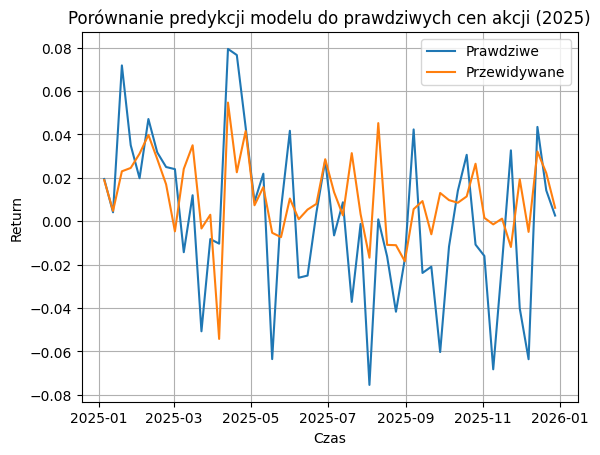

In [ ]:
# @title
plt.plot(df_pred['Data'], y_true, label='Prawdziwe')
plt.plot(df_pred['Data'], y_pred, label='Przewidywane')
plt.title("Porównanie predykcji modelu do prawdziwych cen akcji (2025)")
plt.xlabel("Czas")
plt.ylabel("Return")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# @title
r2 = r2_score(y_true, y_pred)
print(f"R^2 Score: {r2:.4f}")

R^2 Score: 0.1859


Liczymy również współczynnik determinacji modelu $R^2$ (bliski $1$=dobrze, mniejszy =źle). Zarówno wykres jak i $R^2$ pokazują, że model próbuje przewidywać ceny akcji i nie jest źle, natomiast pozostawia on sporo do życzenia.

Średniego wynik poprzedniego modelu może wynikać z tego, że uczymy go na zbyt dużym okresie czasu. Sprawdźmy więc co się stanie jeśli będziemy uczuć model na danych z dokładnie roku wstecz. Zaprezenowane poniżej grafiki pokazują jak zmienia się $\beta$ i $R^2%$ w zależnosci od czasu. Mówiąc prezycyjnie, pierwsza z nich to wykres funkcji która dla pewnego momentu w czasie - $t$ zwraca parametr $\beta$ modelu wytrenowanego na okresie czasu: $(t - \text{rok}, t)$ (analogicznie dla $R^2$).

/tmp/ipykernel_11520/3702413149.py:37: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()


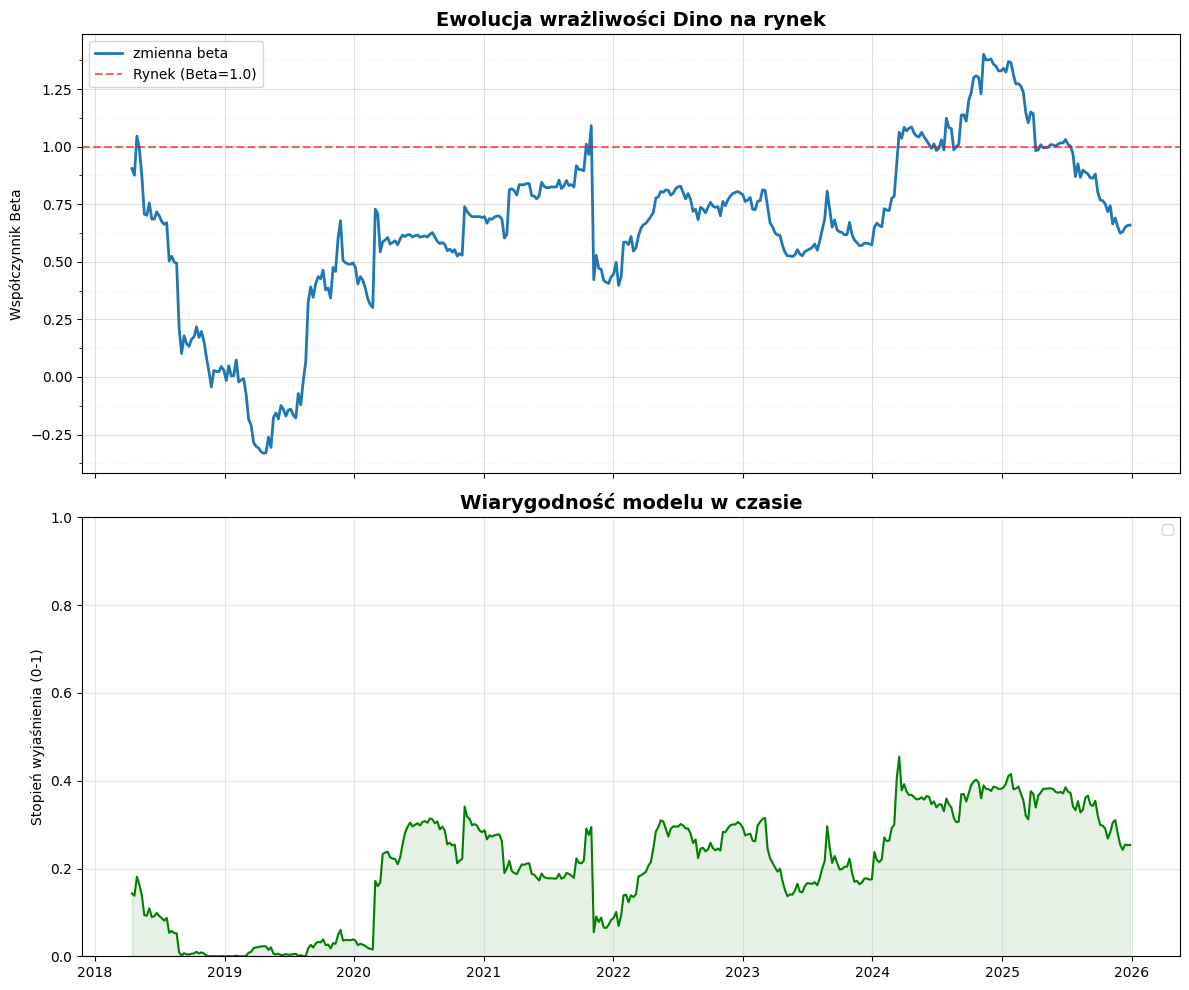

In [ ]:
# @title
df2 = df[df['Data'] <= '2025-12-31'].copy()
df2 = df2.dropna()

window_size = 52
r2 = 0.044 / 52

x2 = df2['K_wig20'] - r2
y2 = df2['K_dnp'] - r2

rolling_cov = y2.rolling(window=window_size).cov(x2)
rolling_var = x2.rolling(window=window_size).var()

rolling_beta = rolling_cov / rolling_var
rolling_r2 = y2.rolling(window=window_size).corr(x2)**2

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,10), sharex=True)

ax1.plot(df2['Data'], rolling_beta, color='#1f77b4', lw=2, label=f'zmienna beta')
ax1.axhline(y=1, color='red', linestyle='--', alpha=0.6, label='Rynek (Beta=1.0)')

ax1.yaxis.set_major_locator(ticker.MultipleLocator(0.25))
ax1.yaxis.set_minor_locator(ticker.MultipleLocator(0.125))
ax1.grid(True, which='major', linestyle='-', alpha=0.4)
ax1.grid(True, which='minor', linestyle=':', alpha=0.2)

ax1.set_title('Ewolucja wrażliwości Dino na rynek', fontsize=14, fontweight='bold')
ax1.set_ylabel('Współczynnik Beta')
ax1.legend()

ax2.fill_between(df2['Data'], rolling_r2, color='green', alpha=0.1)
ax2.plot(df2['Data'], rolling_r2, color='green', lw=1.5, label='')
ax2.set_title('Wiarygodność modelu w czasie', fontsize=14, fontweight='bold')
ax2.set_ylabel('Stopień wyjaśnienia (0-1)')
ax2.set_ylim(0, 1)
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

**Wnioski:** do roku 2020 modele oparte na danych rok wstecz radzą sobie bardzo słabo (prawdopodobnie kwestia początków bycia spółki na giełdzie, Dino weszło na giełdę 9 kwietnia 2017 roku), od 2020 roku wyniki są jednak całkiem przyzwoite. Patrząc na wykres $\beta$ widzimy (po początkowym spadku), że z czasem ryzyko akcji Dino lekko upodabnia sie do ryzyka giełdy.